In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

#解决图像不显示中文的问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体（SimHei）
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示为方块的问题

#数据导入
data_train = pd.read_csv(R"C:\Users\huluye\Desktop\titanic_pytorch\data\train.csv")

#查看所有特征量
print(data_train.info())
print(data_train['Survived'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
Survived
0    549
1    342
Name: count, dtype: int64


train文件一共有891个样本，每个样本一共12个特征量，其中Name、Id、ticket对是否存活没有影响，后续分析不予考虑，其中由于Cabin缺失太多，无法进行补充，直接删除该特征量，Embarked是字符串变量，且缺失样本极少，后续直接删除两个缺失的样本即可，最后对于年龄选择。

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 90.3 KB
None


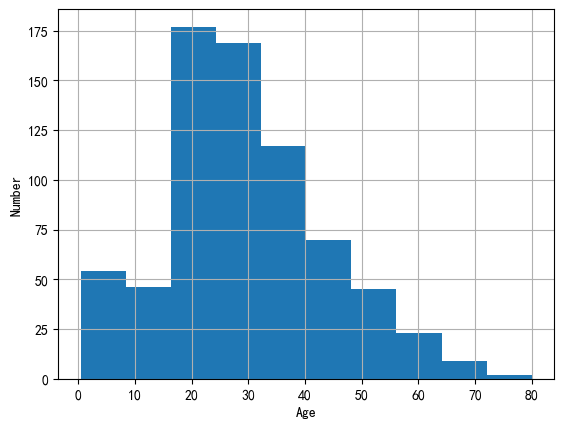

In [3]:
#删除缺失Embarked的两个样本值
data_drop = data_train.dropna(subset=['Embarked'])
print(data_drop.info())

#先查看年龄的结构组成
plt.subplot()
data_drop['Age'].hist()
plt.xlabel('Age')
plt.ylabel('Number')
plt.show()

从上图看出年龄涵盖范围广泛，且总的样本数不多，不能直接设置固定值，采用随机森林算法填充缺失的年龄。

In [4]:
#提取出原数据集中非字符串的特征值
df = data_drop[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']]

train = df[df['Age'].notna()]     #提取出Age没缺失的样本，用于训练
predict = df[df['Age'].isna()]    #提取出Age缺失的样本

x_train = train.drop('Age', axis=1)
y_train = train['Age']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

x_predict = predict.drop('Age', axis=1)
data_predAge = rf.predict(x_predict)

data_drop.loc[data_drop['Age'].isna(), 'Age'] = data_predAge


以上填充年龄的代码只需运行一次

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 90.3 KB
None


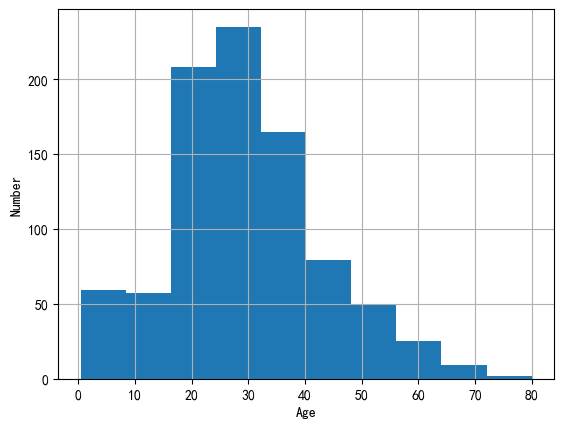

In [5]:
#查看补充缺失的年龄样本后的数据集
print(data_drop.info())
plt.subplot()
data_drop['Age'].hist()
plt.xlabel('Age')
plt.ylabel('Number')
plt.show()

年龄填充完毕后，将不考虑的特征量剔除，查看所有特征量与是否存活之间的关系。

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    str    
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 62.5 KB
None
Age_cut
15-60岁    772
15岁及以下     94
60岁以上      22
Name: count, dtype: int64


Text(0.5, 1.0, '不同登船港口与是否存活的关系')

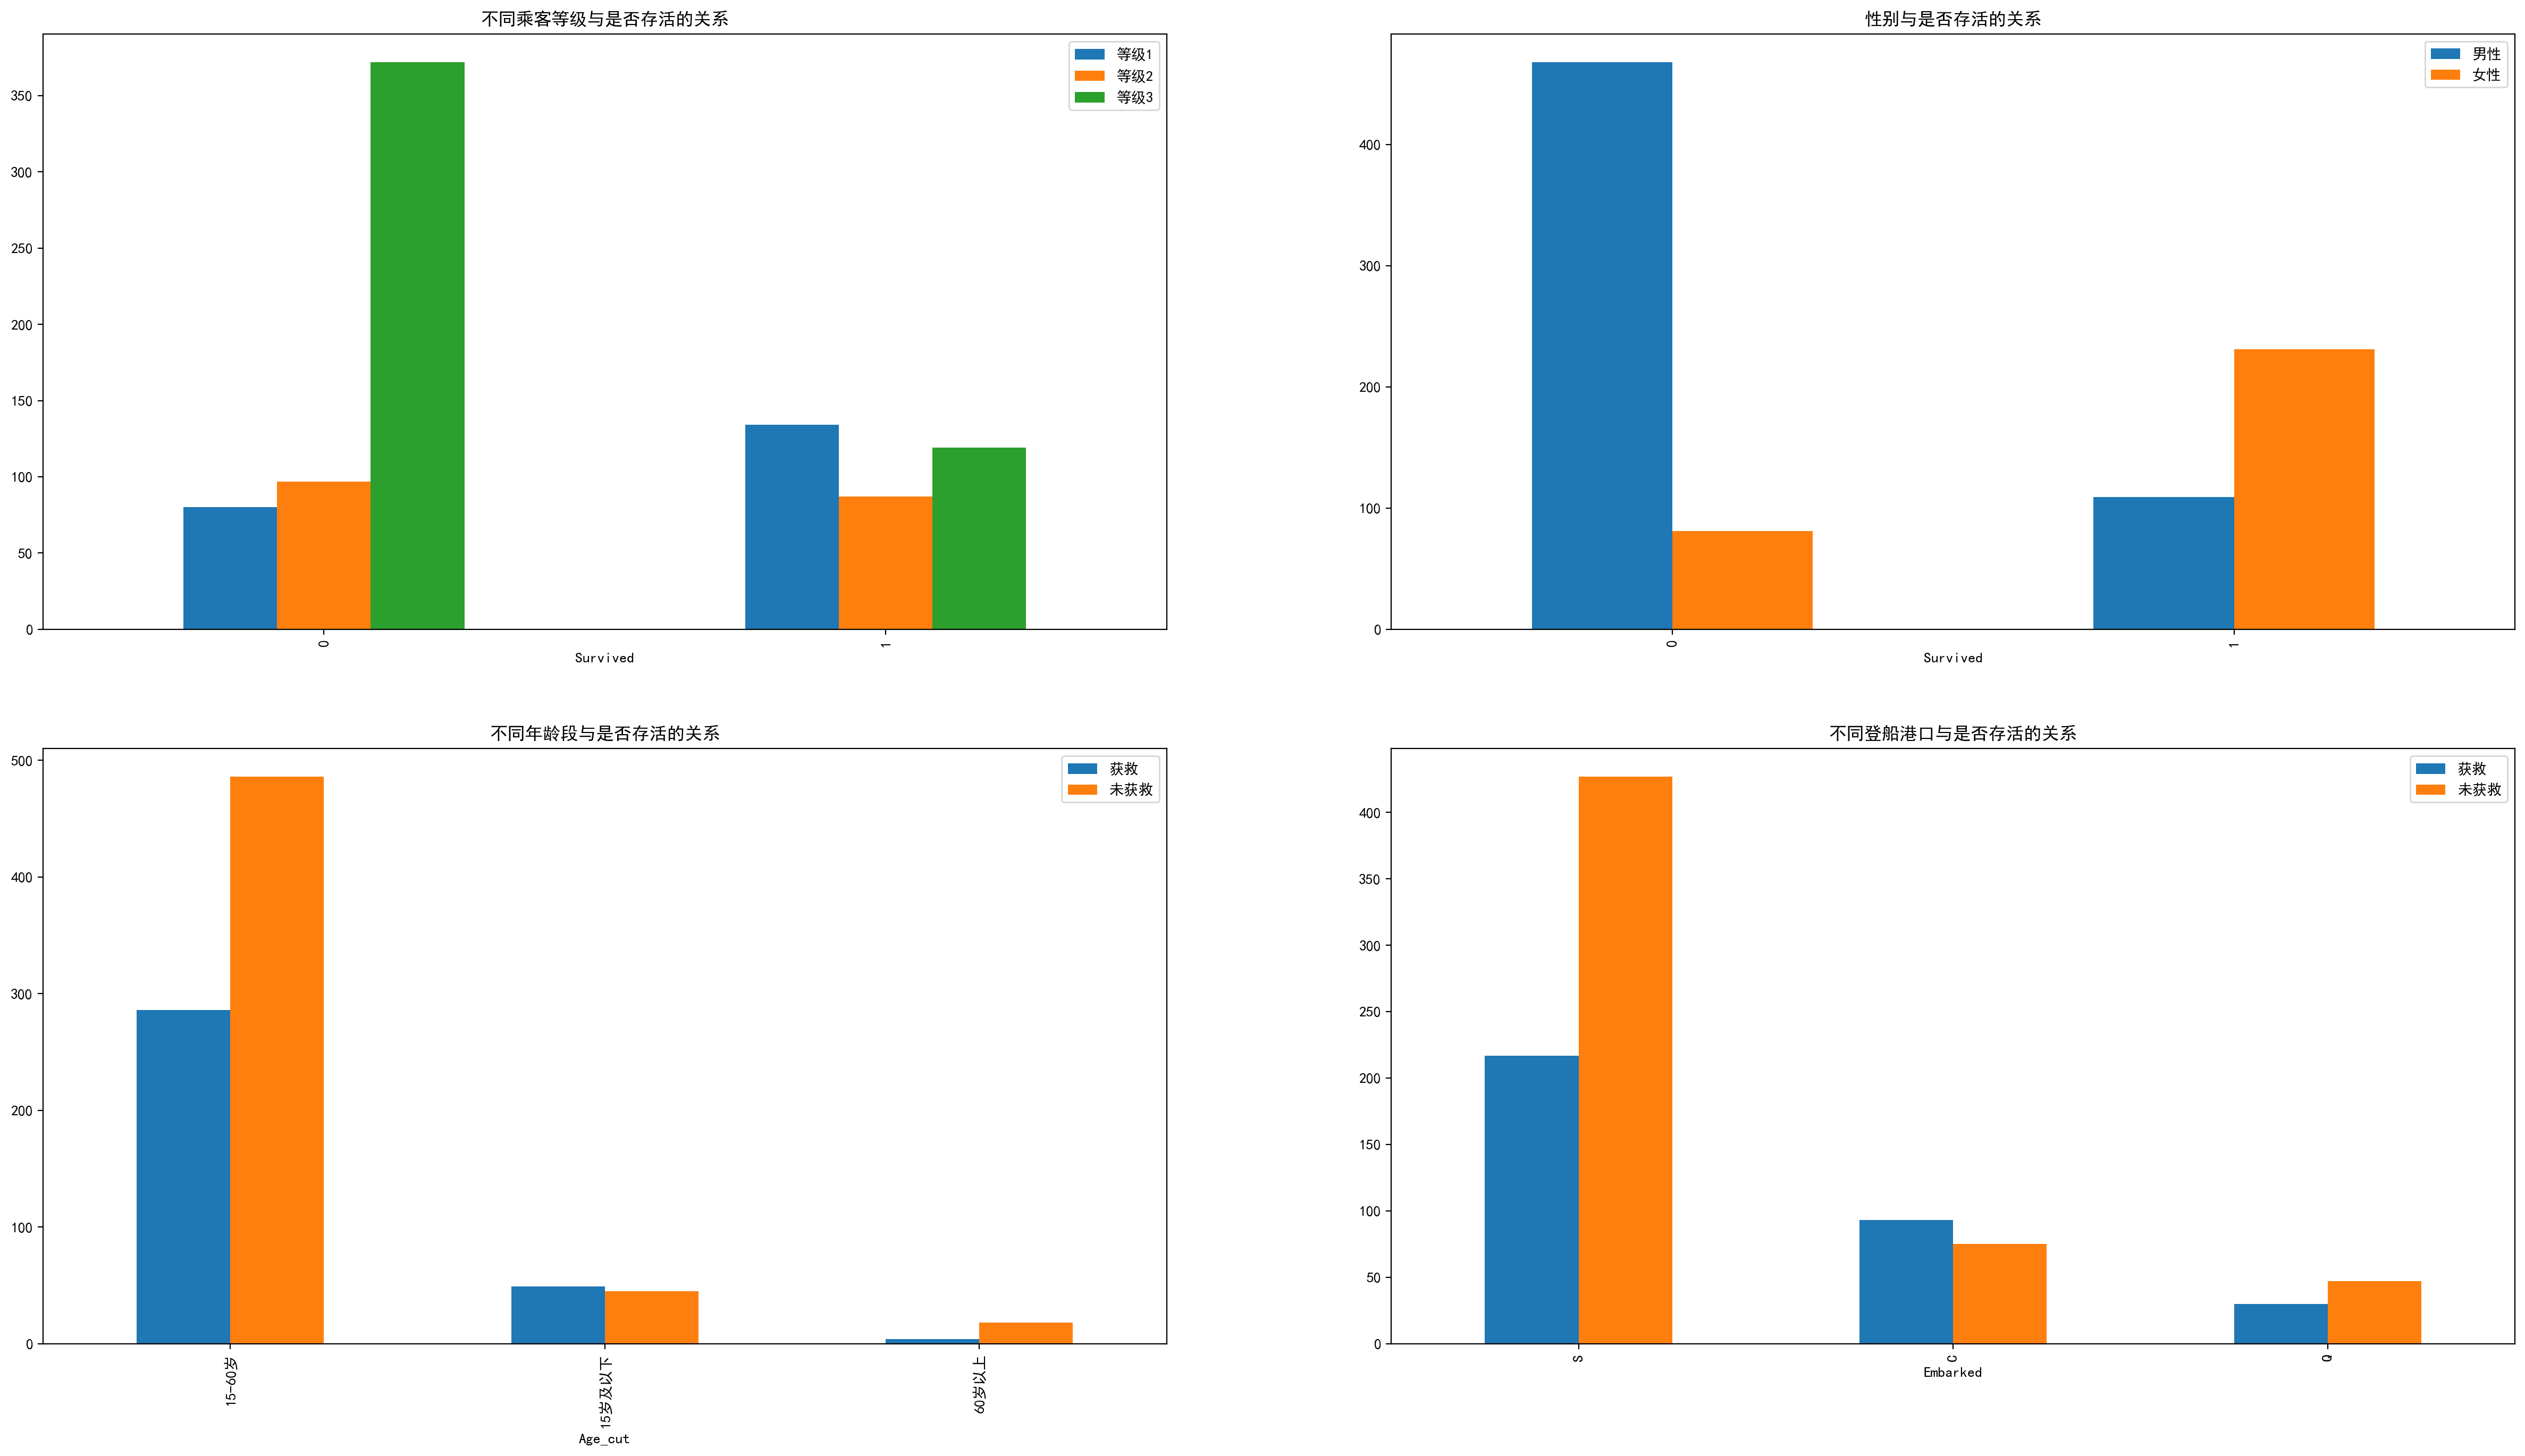

In [6]:
#剔除不需要的特征量
df_train = data_drop.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print(df_train.info())
#定义绘制区域
plt.figure(figsize=(30, 16), dpi=200)
#绘制不同特征量与是否存活的关系图
p1 = plt.subplot(221)
Pclass0 = df_train.loc[df_train['Pclass'] == 1, 'Survived'].value_counts()
Pclass1 = df_train.loc[df_train['Pclass'] == 2, 'Survived'].value_counts()
Pclass2 = df_train.loc[df_train['Pclass'] == 3, 'Survived'].value_counts()
df_pclass = pd.DataFrame({'等级1':Pclass0, '等级2':Pclass1, '等级3':Pclass2})
df_pclass.plot(kind='bar', ax=p1)
plt.title('不同乘客等级与是否存活的关系')

p2 = plt.subplot(222)
man = df_train.loc[df_train['Sex'] == 'male', 'Survived'].value_counts()
woman = df_train.loc[df_train['Sex'] == 'female', 'Survived'].value_counts()
df_pclass = pd.DataFrame({'男性':man, '女性':woman})
df_pclass.plot(kind='bar', ax=p2)
plt.title('性别与是否存活的关系')

p3 = plt.subplot(223)
bins = [min(df_train['Age']), 15, 60, max(df_train['Age'])]
bins_label = ['15岁及以下', '15-60岁', '60岁以上']
df_train['Age_cut'] = pd.cut(df_train['Age'], bins=bins, labels=bins_label)
print(df_train['Age_cut'].value_counts())
Age_0 = df_train.loc[df_train['Survived'] ==0, 'Age_cut'].value_counts()
Age_1 = df_train.loc[df_train['Survived'] ==1, 'Age_cut'].value_counts()
df_age = pd.DataFrame({'获救': Age_1, '未获救': Age_0})
df_age.plot(kind='bar', ax=p3)
plt.title('不同年龄段与是否存活的关系')

p4 = plt.subplot(224)
Embarked_0 = df_train.loc[df_train['Survived'] == 0, 'Embarked'].value_counts()
Embarked_1 = df_train.loc[df_train['Survived'] == 1, 'Embarked'].value_counts()
df_Embarked = pd.DataFrame({'获救':Embarked_1, '未获救': Embarked_0})
df_Embarked.plot(kind='bar', ax=p4)
plt.title('不同登船港口与是否存活的关系')



从以上四张柱状图可以看出这四个特征量与是否存活之间有较强的关联性，所以在后续训练模型时主要考虑这四个特征量。

In [ ]:
df_train = df_train.drop(columns=['Age_cut', 'SibSp', 'Parch', 'Fare'])
df_train.to_csv(R"C:\Users\huluye\Desktop\titanic_pytorch\processed_data\df_train.csv")


<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    str    
 3   Age       889 non-null    float64
 4   Embarked  889 non-null    str    
dtypes: float64(1), int64(2), str(2)
memory usage: 41.7 KB
None
